In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams
import scipy.stats as stats

In [2]:
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [3]:
## path variables
data_dir = '/home/niklas/projects/GLPG_drug_perturbations/01_data/'
out_dir = '/home/niklas/projects/GLPG_drug_perturbations/02_figures/fig3/'

In [4]:
## read metadata frame
metadata = pd.read_csv(data_dir + '20201117_GLPG_metadata.csv', sep=',', index_col = 'identifier')
metadata.head(5)

,group,time_point,ChromiumBatch,LibraryPrepBatch,SeqBatch,ashcroft_score,body_weight_d0,body_weight_d1,body_weight_d2,body_weight_d3,...,body_weight_d17,body_weight_d18,body_weight_d19,body_weight_d20,body_weight_d21,body_weight_min,body_weight_max,delta_max_body_weight,delta_body_weight_d7_10,delta_body_weight_d14_d21
identifier,,,,,,,,,,,,,,,,,,,,,
d10BLM_Combo39,BLM_Combo,d10,run 1,Lib1,Seq1,2.2500,23.5,22.3,22.4,22.9,...,NaN,NaN,NaN,NaN,NaN,21.0,23.5,-2.5,-2.5,NaN
d10BLM_Combo41,BLM_Combo,d10,run 3,Lib1,Seq3,2.5625,23.8,22.4,23.4,23.7,...,NaN,NaN,NaN,NaN,NaN,22.4,24.0,-1.4,-0.5,NaN
d10BLM_Combo42,BLM_Combo,d10,run 2,Lib1,Seq2,2.6875,24.6,24.1,24.0,24.4,...,NaN,NaN,NaN,NaN,NaN,22.0,24.6,-2.6,-1.4,NaN
d10BLM_Combo43,BLM_Combo,d10,run 4,Lib3,Seq4,1.7500,25.8,25.3,24.8,25.1,...,NaN,NaN,NaN,NaN,NaN,23.0,25.8,-2.8,-2.8,NaN
d10BLM_Combo44,BLM_Combo,d10,run 5,Lib3,Seq5,1.5625,23.5,23.0,22.9,22.9,...,NaN,NaN,NaN,NaN,NaN,22.9,24.5,-0.6,0.2,NaN


In [5]:
## rename 'group' columns
treatment_mapping = {
    'BLM_GLPG1205' : 'Bleo+GLPG1205',
    'BLM_Nintedanib' : 'Bleo_Nintedanib',
    'BLM_GLPG1690' : 'Bleo+GLPG1690',
    'BLM_Combo' : 'Bleo+GLPG Combo',
    'BLM_vehicle' : 'Bleo',
    'Sham' : 'PBS'    
}
metadata['treatment'] = metadata['group'].replace(treatment_mapping)
metadata.head(5)

,group,time_point,ChromiumBatch,LibraryPrepBatch,SeqBatch,ashcroft_score,body_weight_d0,body_weight_d1,body_weight_d2,body_weight_d3,...,body_weight_d18,body_weight_d19,body_weight_d20,body_weight_d21,body_weight_min,body_weight_max,delta_max_body_weight,delta_body_weight_d7_10,delta_body_weight_d14_d21,treatment
identifier,,,,,,,,,,,,,,,,,,,,,
d10BLM_Combo39,BLM_Combo,d10,run 1,Lib1,Seq1,2.2500,23.5,22.3,22.4,22.9,...,NaN,NaN,NaN,NaN,21.0,23.5,-2.5,-2.5,NaN,Bleo+GLPG Combo
d10BLM_Combo41,BLM_Combo,d10,run 3,Lib1,Seq3,2.5625,23.8,22.4,23.4,23.7,...,NaN,NaN,NaN,NaN,22.4,24.0,-1.4,-0.5,NaN,Bleo+GLPG Combo
d10BLM_Combo42,BLM_Combo,d10,run 2,Lib1,Seq2,2.6875,24.6,24.1,24.0,24.4,...,NaN,NaN,NaN,NaN,22.0,24.6,-2.6,-1.4,NaN,Bleo+GLPG Combo
d10BLM_Combo43,BLM_Combo,d10,run 4,Lib3,Seq4,1.7500,25.8,25.3,24.8,25.1,...,NaN,NaN,NaN,NaN,23.0,25.8,-2.8,-2.8,NaN,Bleo+GLPG Combo
d10BLM_Combo44,BLM_Combo,d10,run 5,Lib3,Seq5,1.5625,23.5,23.0,22.9,22.9,...,NaN,NaN,NaN,NaN,22.9,24.5,-0.6,0.2,NaN,Bleo+GLPG Combo


In [6]:
## order of treatments for plotting
treatment_order = ['PBS', 'Bleo', 'Bleo_Nintedanib','Bleo+GLPG1205','Bleo+GLPG1690','Bleo+GLPG Combo'] 

In [7]:
## color palette for plotting
treatment_colors = ['#D3D3D3', '#606060', '#2E59A8', '#FFA500', '#C93333', '#20B2AA']

In [8]:
## define baseline for stat testing
baseline = 'Bleo'

In [9]:
to_test = 'ashcroft_score'

### Data visualization: check of normality for Ashcroft score and body weight loss?

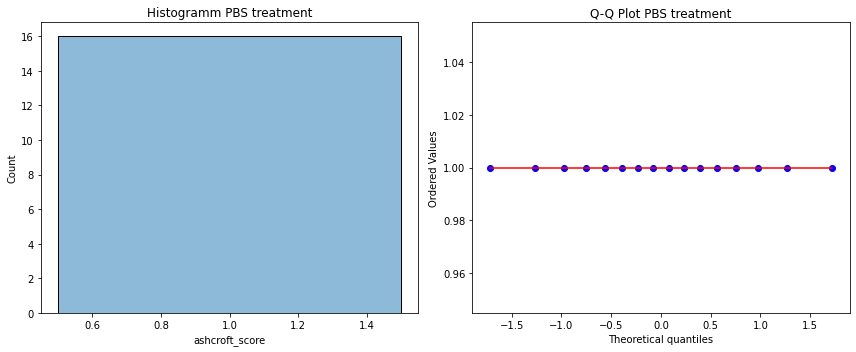

/home/niklas/miniconda3/envs/niche_fibrosis_env/lib/python3.8/site-packages/scipy/stats/morestats.py:1757: UserWarning: Input data for shapiro has range zero. The results may not be accurate.
  warnings.warn("Input data for shapiro has range zero. The results "


Shapiro-Wilk Test for PBS treatment: Statistic=1.0, p-value=1.0


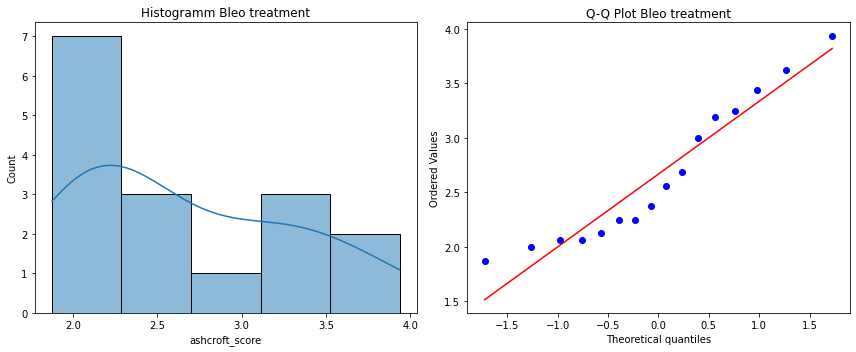

Shapiro-Wilk Test for Bleo treatment: Statistic=0.9115585088729858, p-value=0.12330317497253418


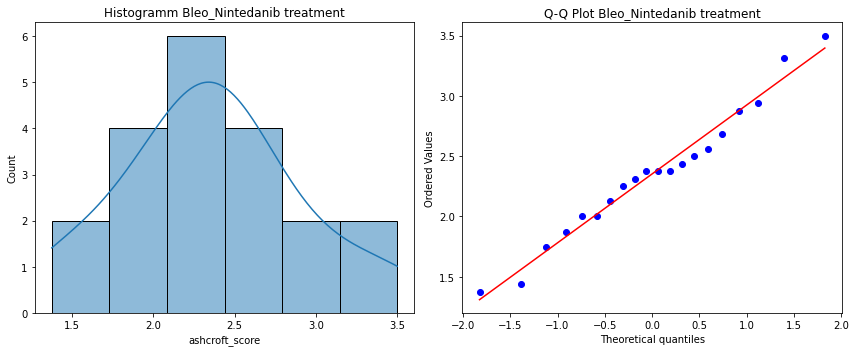

Shapiro-Wilk Test for Bleo_Nintedanib treatment: Statistic=0.9760258197784424, p-value=0.8732277750968933


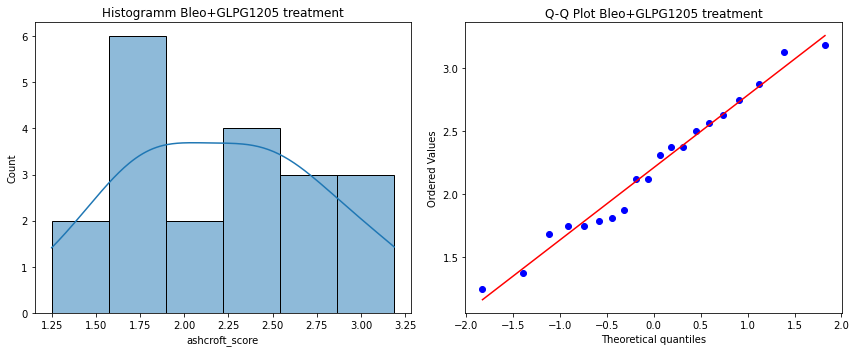

Shapiro-Wilk Test for Bleo+GLPG1205 treatment: Statistic=0.9700031876564026, p-value=0.7549411654472351


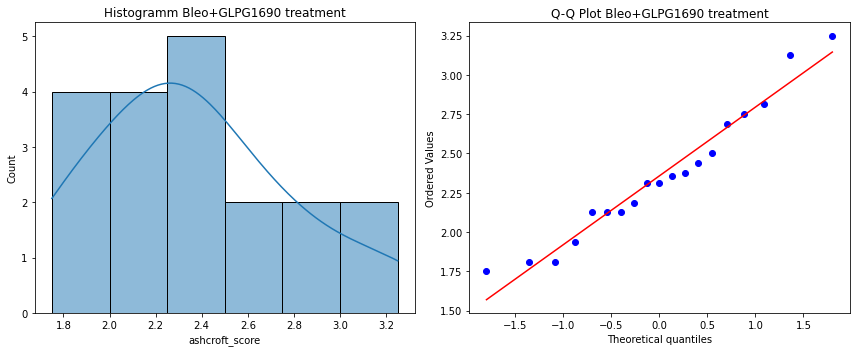

Shapiro-Wilk Test for Bleo+GLPG1690 treatment: Statistic=0.9526025652885437, p-value=0.4370689392089844


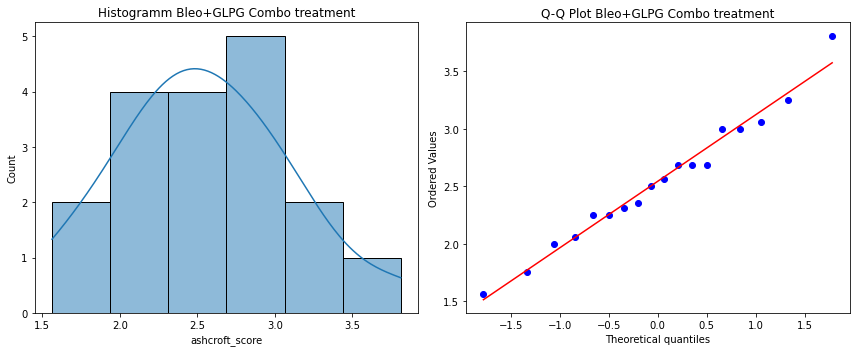

Shapiro-Wilk Test for Bleo+GLPG Combo treatment: Statistic=0.9824061989784241, p-value=0.9713850617408752


In [10]:
## ideally data within each treatment group should be normally distributed
for treatment in treatment_order:
    ## subset data
    df = metadata[metadata['treatment'] == treatment]
    
    ## overall histogram and Q-Q plot for ashcroft scores
    plt.figure(figsize=(12, 5))

    ## histogram
    plt.subplot(1, 2, 1)
    sb.histplot(df[to_test], kde=True)
    plt.title(f'Histogramm {treatment} treatment')
    
    # Q-Q plot
    plt.subplot(1, 2, 2)
    stats.probplot(df[to_test], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot {treatment} treatment')
    plt.tight_layout()
    plt.show()
    
    shapiro_stat, shapiro_p_value = stats.shapiro(df[df['treatment'] == treatment][to_test])
    print(f'Shapiro-Wilk Test for {treatment} treatment: Statistic={shapiro_stat}, p-value={shapiro_p_value}')

### Boxplot of results

In [11]:
## ashcroft scores seem to be normally distributed, so we can go ahead with t-test
from scipy.stats import ttest_ind

In [12]:
# Function to calculate p-values and significance stars
def add_significance(df, baseline_treatment, treatments, y_offset=0.1):
    comparisons = []
    for treatment in treatments:
        if treatment != baseline_treatment:
            _, p_value = ttest_ind(
                df[df['treatment'] == baseline_treatment]['ashcroft_score'],
                df[df['treatment'] == treatment]['ashcroft_score'],
                equal_var=False # Welch's t-test to handle unequal variances
            )
            if p_value < 0.001:
                comparisons.append((treatment, f'*** \n(p = {round(p_value, 3)})', p_value))
            elif p_value < 0.01:
                comparisons.append((treatment, f'** \n(p = {round(p_value, 3)})', p_value))
            elif p_value < 0.05:
                comparisons.append((treatment, f'* \n(p = {round(p_value, 3)})', p_value))
            else:
                comparisons.append((treatment, f'ns', p_value))
    return comparisons

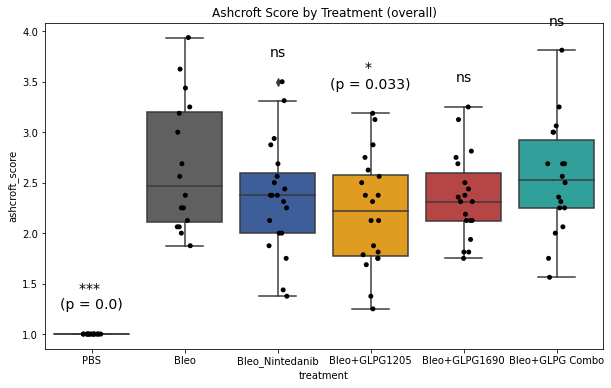

In [13]:
## overall boxplot of Ashcroft score by treatment
plt.figure(figsize=(10, 6))
ax = sb.boxplot(x='treatment', y='ashcroft_score', data=metadata, order=treatment_order, palette=treatment_colors)
## add individual data points as black dots
sb.stripplot(x='treatment', y='ashcroft_score', data=metadata, order=treatment_order, color='black', size=5, jitter=True, ax=ax)
plt.title('Ashcroft Score by Treatment (overall)')

## add significance stars
comparisons = add_significance(metadata, baseline, treatment_order)
for treatment, significance, _ in comparisons:
    y_max = metadata[metadata['treatment'] == treatment]['ashcroft_score'].max() + 0.15
    ax.annotate(significance, xy=(treatment_order.index(treatment), y_max), 
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=14, color='black')
    
## save figure as PDF
plt.savefig(out_dir + 'boxplot_ashcroft_score_overall.pdf')

plt.show()

/tmp/ipykernel_1000877/3924476137.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y_max = metadata[metadata['time_point'] == 'd10'][metadata['treatment'] == treatment]['ashcroft_score'].max() + 0.15


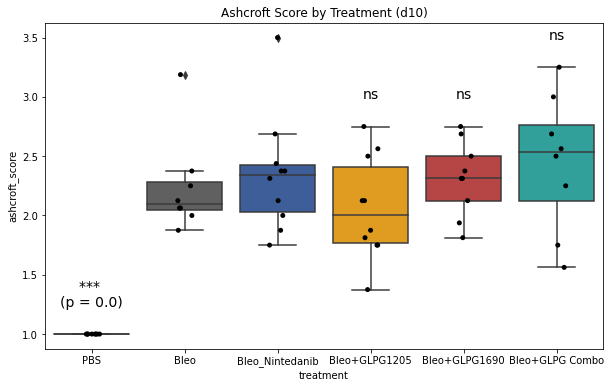

In [14]:
## boxplot for ashcroft score by treatment at time point d10
plt.figure(figsize=(10, 6))
ax = sb.boxplot(x='treatment', y='ashcroft_score', data=metadata[metadata['time_point'] == 'd10'], order=treatment_order, palette=treatment_colors)
## add individual data points as black dots
sb.stripplot(x='treatment', y='ashcroft_score', data=metadata[metadata['time_point'] == 'd10'], order=treatment_order, color='black', size=5, jitter=True, ax=ax)
plt.title('Ashcroft Score by Treatment (d10)')

## add significance stars
comparisons = add_significance(metadata[metadata['time_point'] == 'd10'], baseline, treatment_order)
for treatment, significance, _ in comparisons:
    y_max = metadata[metadata['time_point'] == 'd10'][metadata['treatment'] == treatment]['ashcroft_score'].max() + 0.15
    ax.annotate(significance, xy=(treatment_order.index(treatment), y_max), 
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=14, color='black')

## save figure as PDF
plt.savefig(out_dir + 'boxplot_ashcroft_score_d10.pdf')

plt.show()

/tmp/ipykernel_1000877/534661248.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  y_max = metadata[metadata['time_point'] == 'd21'][metadata['treatment'] == treatment]['ashcroft_score'].max() + 0.15


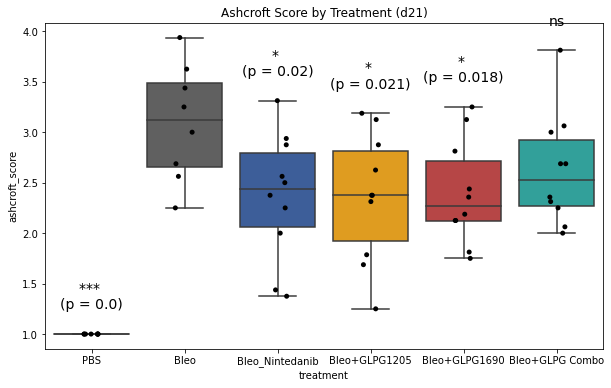

In [15]:
# boxplot for ashcroft score by treatment at time point d21
plt.figure(figsize=(10, 6))
ax = sb.boxplot(x='treatment', y='ashcroft_score', data=metadata[metadata['time_point'] == 'd21'], order=treatment_order, palette = treatment_colors)
## add individual data points as black dots
sb.stripplot(x='treatment', y='ashcroft_score', data=metadata[metadata['time_point'] == 'd21'], order=treatment_order, color='black', size=5, jitter=True, ax=ax)
plt.title('Ashcroft Score by Treatment (d21)')
          
## add significance stars
comparisons = add_significance(metadata[metadata['time_point'] == 'd21'], baseline, treatment_order)
for treatment, significance, _ in comparisons:
    y_max = metadata[metadata['time_point'] == 'd21'][metadata['treatment'] == treatment]['ashcroft_score'].max() + 0.15
    ax.annotate(significance, xy=(treatment_order.index(treatment), y_max), 
                xytext=(0, 10), textcoords='offset points', ha='center', fontsize=14, color='black')

## save figure as PDF
plt.savefig(out_dir + 'boxplot_ashcroft_score_d21.pdf')
    
plt.show()